# Análise Exploratória do Empreendedorismo em Santa Catarina

## Objetivo
Realizar uma análise exploratória de dados (AED) sobre o cenário empreendedor do estado de Santa Catarina, investigando padrões de abertura de empresas, distribuição por setores econômicos, portes empresariais e regiões do estado.

## Conjunto de Dados
Dataset simulado com **5.000 registros** de empresas catarinenses, contendo informações como município, setor de atuação, porte, capital social, número de funcionários, faturamento estimado e situação cadastral. Os dados foram modelados com base em distribuições proporcionais reais de atividade econômica do estado.

## Etapas da Análise
1. Carregamento e inspeção dos dados
2. Tratamento de valores ausentes e inconsistentes
3. Análise estatística descritiva
4. Visualizações por setor, porte, município e região
5. Análise temporal de abertura e fechamento de empresas
6. Conclusões e insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Carregamento e Inspeção dos Dados

In [2]:
df = pd.read_csv('../data/empresas_sc.csv')

print(f"Shape do dataset: {df.shape}")
print(f"\nTotal de registros: {df.shape[0]:,}")
print(f"Total de colunas: {df.shape[1]}")
print(f"\nColunas disponíveis:")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

Shape do dataset: (5000, 13)

Total de registros: 5,000
Total de colunas: 13

Colunas disponíveis:
  - id (int64)
  - cnpj (str)
  - municipio (str)
  - mesorregiao (str)
  - setor (str)
  - porte (str)
  - natureza_juridica (str)
  - capital_social (float64)
  - num_funcionarios (float64)
  - faturamento_anual_estimado (float64)
  - data_abertura (str)
  - situacao (str)
  - data_situacao (str)


In [3]:
# Primeiros registros
df.head(10)

,id,cnpj,municipio,mesorregiao,setor,porte,natureza_juridica,capital_social,num_funcionarios,faturamento_anual_estimado,data_abertura,situacao,data_situacao
0,1,83.863.794/0265-42,Balneário Camboriú,Vale do Itajaí,Comércio varejista,MEI,Empresário Individual,14992.95,0.0,52743.98,2020-07-25,Ativa,NaN
1,2,61.849.593/1034-13,Joinville,Norte Catarinense,Transporte e logística,MEI,Empresário Individual,7820.61,1.0,53657.10,2020-02-01,Ativa,NaN
2,3,83.276.483/5030-56,Caçador,Oeste Catarinense,Serviços profissionais,MEI,Empresário Individual,8033.44,0.0,58242.09,2020-10-28,Ativa,NaN
3,4,84.969.653/2871-01,Blumenau,Vale do Itajaí,Comércio varejista,Média,Sociedade Anônima Fechada,33116494.60,151.0,44787678.56,2021-05-20,Ativa,NaN
4,5,84.514.627/0482-81,Joinville,Norte Catarinense,Comércio varejista,ME,Sociedade Limitada,144668.56,8.0,-1.00,2019-09-18,Suspensa,NaN
5,6,01.543.039/1171-82,Caçador,Oeste Catarinense,Alimentação e bebidas,ME,Sociedade Limitada,63493.74,3.0,-1.00,2021-03-25,Suspensa,NaN
6,7,65.787.133/1509-83,Joinville,Norte Catarinense,Construção civil,MEI,Empresário Individual,17576.23,1.0,78541.04,2024-12-01,Ativa,NaN
7,8,29.973.763/1165-66,Lages,Serrana,Comércio varejista,ME,Sociedade Limitada,33590.11,1.0,320838.28,2021-07-26,Ativa,NaN
8,9,24.731.781/0801-32,Criciúma,Sul Catarinense,Transporte e logística,ME,Sociedade Limitada,150917.45,6.0,304365.31,2019-09-06,Ativa,NaN
9,10,87.234.309/8050-09,Chapecó,Oeste Catarinense,Construção civil,EPP,Sociedade Limitada,2042640.65,34.0,1537501.58,2020-11-05,Ativa,NaN


In [4]:
# Informações gerais do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          5000 non-null   int64  
 1   cnpj                        5000 non-null   str    
 2   municipio                   4940 non-null   str    
 3   mesorregiao                 5000 non-null   str    
 4   setor                       5000 non-null   str    
 5   porte                       5000 non-null   str    
 6   natureza_juridica           5000 non-null   str    
 7   capital_social              4899 non-null   float64
 8   num_funcionarios            4863 non-null   float64
 9   faturamento_anual_estimado  5000 non-null   float64
 10  data_abertura               5000 non-null   str    
 11  situacao                    5000 non-null   str    
 12  data_situacao               688 non-null    str    
dtypes: float64(3), int64(1), str(9)
memory usage

## 2. Tratamento de Valores Ausentes e Inconsistentes

Antes de iniciar a análise, é necessário identificar e tratar:
- Valores nulos/ausentes
- Valores inconsistentes (ex: faturamento negativo)
- Campos vazios em colunas categóricas

In [5]:
# Verificar valores ausentes
print("=== Valores Ausentes por Coluna ===\n")
ausentes = df.isnull().sum()
ausentes_pct = (df.isnull().sum() / len(df) * 100).round(2)
resumo_ausentes = pd.DataFrame({
    'Ausentes': ausentes,
    'Percentual (%)': ausentes_pct
})
print(resumo_ausentes[resumo_ausentes['Ausentes'] > 0])

# Verificar strings vazias
print("\n=== Campos com Strings Vazias ===")
for col in df.select_dtypes(include='object').columns:
    vazios = (df[col] == '').sum()
    if vazios > 0:
        print(f"  {col}: {vazios} registros vazios")

=== Valores Ausentes por Coluna ===

                  Ausentes  Percentual (%)
municipio               60            1.20
capital_social         101            2.02
num_funcionarios       137            2.74
data_situacao         4312           86.24

=== Campos com Strings Vazias ===


In [6]:
# Verificar valores inconsistentes no faturamento
inconsistentes = df[df['faturamento_anual_estimado'] < 0]
print(f"Registros com faturamento negativo: {len(inconsistentes)}")
if len(inconsistentes) > 0:
    print(inconsistentes[['id', 'municipio', 'setor', 'faturamento_anual_estimado']])

Registros com faturamento negativo: 96
        id      municipio                   setor  faturamento_anual_estimado
4        5      Joinville      Comércio varejista                        -1.0
5        6        Caçador   Alimentação e bebidas                        -1.0
75      76      Joinville       Saúde e bem-estar                        -1.0
143    144        Tubarão      Comércio varejista                        -1.0
177    178       Blumenau       Saúde e bem-estar                        -1.0
...    ...            ...                     ...                         ...
4764  4765        Caçador       Beleza e estética                        -1.0
4786  4787        Caçador             Imobiliário                        -1.0
4838  4839        Chapecó      Comércio varejista                        -1.0
4853  4854        Palhoça             Imobiliário                        -1.0
4970  4971  Florianópolis  Transporte e logística                        -1.0

[96 rows x 4 columns]


In [7]:
# === TRATAMENTO ===

# 1. Substituir strings vazias em município por 'Não informado'
df['municipio'] = df['municipio'].replace('', 'Não informado')
df.loc[df['municipio'] == 'Não informado', 'mesorregiao'] = 'Não informada'

# 2. Preencher num_funcionarios nulo com a mediana do porte
for porte in df['porte'].unique():
    mediana = df.loc[df['porte'] == porte, 'num_funcionarios'].median()
    mask = (df['porte'] == porte) & (df['num_funcionarios'].isnull())
    df.loc[mask, 'num_funcionarios'] = mediana

df['num_funcionarios'] = df['num_funcionarios'].astype(int)

# 3. Substituir capital_social nulo pela mediana do porte
for porte in df['porte'].unique():
    mediana = df.loc[df['porte'] == porte, 'capital_social'].median()
    mask = (df['porte'] == porte) & (df['capital_social'].isnull())
    df.loc[mask, 'capital_social'] = mediana

# 4. Corrigir faturamento negativo (substituir pela mediana do porte)
for porte in df['porte'].unique():
    mediana = df.loc[
        (df['porte'] == porte) & (df['faturamento_anual_estimado'] > 0),
        'faturamento_anual_estimado'
    ].median()
    mask = (df['porte'] == porte) & (df['faturamento_anual_estimado'] < 0)
    df.loc[mask, 'faturamento_anual_estimado'] = mediana

# 5. Converter datas
df['data_abertura'] = pd.to_datetime(df['data_abertura'])
df['ano_abertura'] = df['data_abertura'].dt.year
df['mes_abertura'] = df['data_abertura'].dt.month

print("Tratamento concluído!")
print(f"\nValores ausentes restantes: {df.isnull().sum().sum()}")
print(f"Valores negativos no faturamento: {(df['faturamento_anual_estimado'] < 0).sum()}")

Tratamento concluído!

Valores ausentes restantes: 4372
Valores negativos no faturamento: 0


## 3. Análise Estatística Descritiva

In [8]:
# Estatísticas descritivas das variáveis numéricas
desc = df[['capital_social', 'num_funcionarios', 'faturamento_anual_estimado']].describe()
desc.loc['total'] = df[['capital_social', 'num_funcionarios', 'faturamento_anual_estimado']].sum()
print("=== Estatísticas Descritivas ===\n")
desc

=== Estatísticas Descritivas ===



,capital_social,num_funcionarios,faturamento_anual_estimado
count,5.000000e+03,5000.000000,5.000000e+03
mean,6.651617e+06,34.329000,6.935653e+06
std,3.972101e+07,165.627372,4.108068e+07
min,1.001110e+03,0.000000,1.211369e+04
25%,9.681900e+03,0.000000,4.350221e+04
50%,1.775289e+04,1.000000,7.383641e+04
75%,2.748254e+05,7.250000,2.941231e+05
max,4.928911e+08,1972.000000,4.996676e+08
total,3.325809e+10,171645.000000,3.467827e+10


In [9]:
# Distribuição por situação cadastral
print("=== Situação Cadastral ===\n")
situacao_counts = df['situacao'].value_counts()
situacao_pct = (situacao_counts / len(df) * 100).round(1)
for sit, count in situacao_counts.items():
    print(f"  {sit}: {count:,} empresas ({situacao_pct[sit]}%)")

print(f"\nTaxa de mortalidade empresarial: {situacao_pct.get('Baixada', 0):.1f}%")

=== Situação Cadastral ===

  Ativa: 3,818 empresas (76.4%)
  Baixada: 688 empresas (13.8%)
  Suspensa: 494 empresas (9.9%)

Taxa de mortalidade empresarial: 13.8%


## 4. Visualizações

### 4.1 Distribuição por Setor Econômico

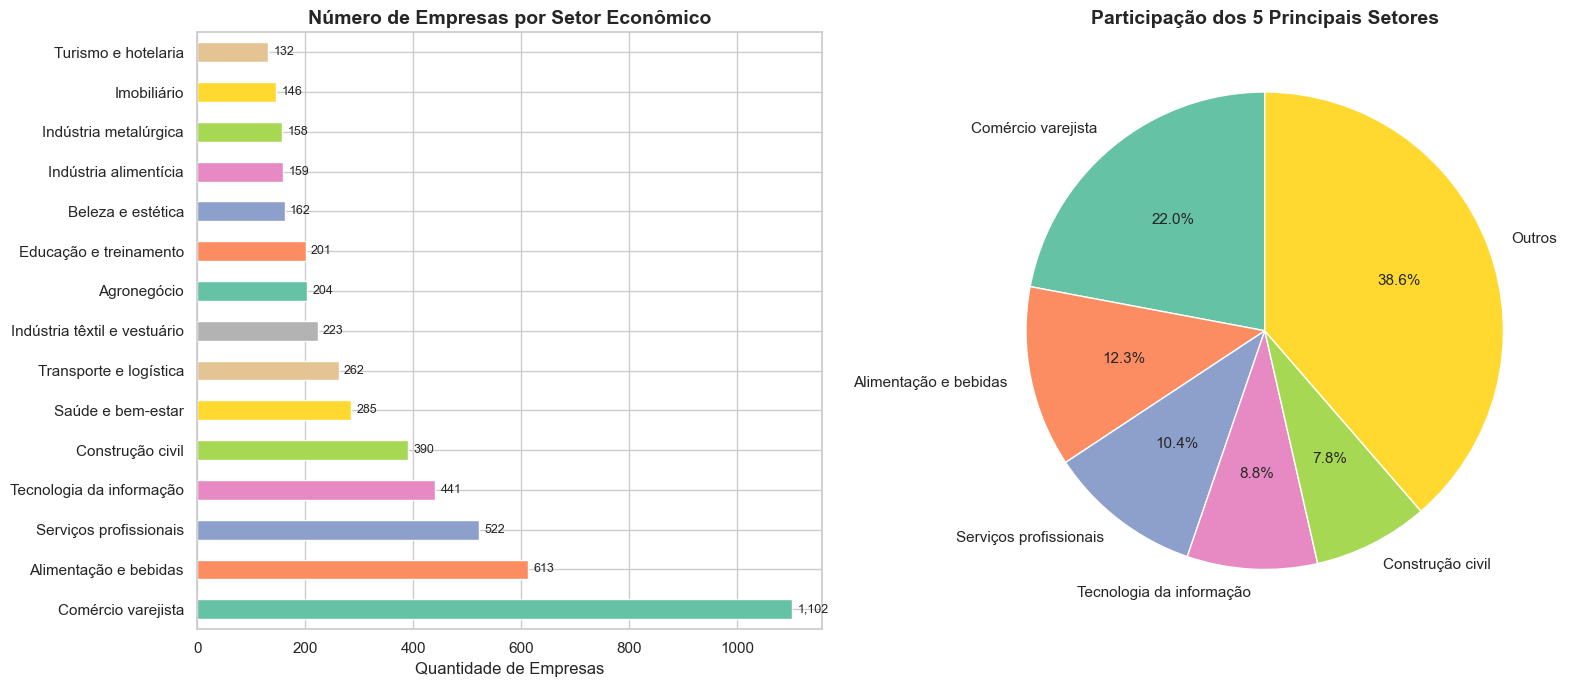

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico de barras horizontal - Top setores
setor_counts = df['setor'].value_counts()
colors = sns.color_palette('Set2', len(setor_counts))
setor_counts.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Número de Empresas por Setor Econômico', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quantidade de Empresas')
axes[0].set_ylabel('')

for i, (val, name) in enumerate(zip(setor_counts.values, setor_counts.index)):
    axes[0].text(val + 10, i, f'{val:,}', va='center', fontsize=9)

# Gráfico de pizza - Top 5 setores
top5 = setor_counts.head(5)
outros = pd.Series({'Outros': setor_counts.tail(len(setor_counts) - 5).sum()})
pizza_data = pd.concat([top5, outros])
pizza_data.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
                colors=sns.color_palette('Set2', len(pizza_data)))
axes[1].set_title('Participação dos 5 Principais Setores', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../outputs/setores_economicos.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.2 Distribuição por Porte Empresarial

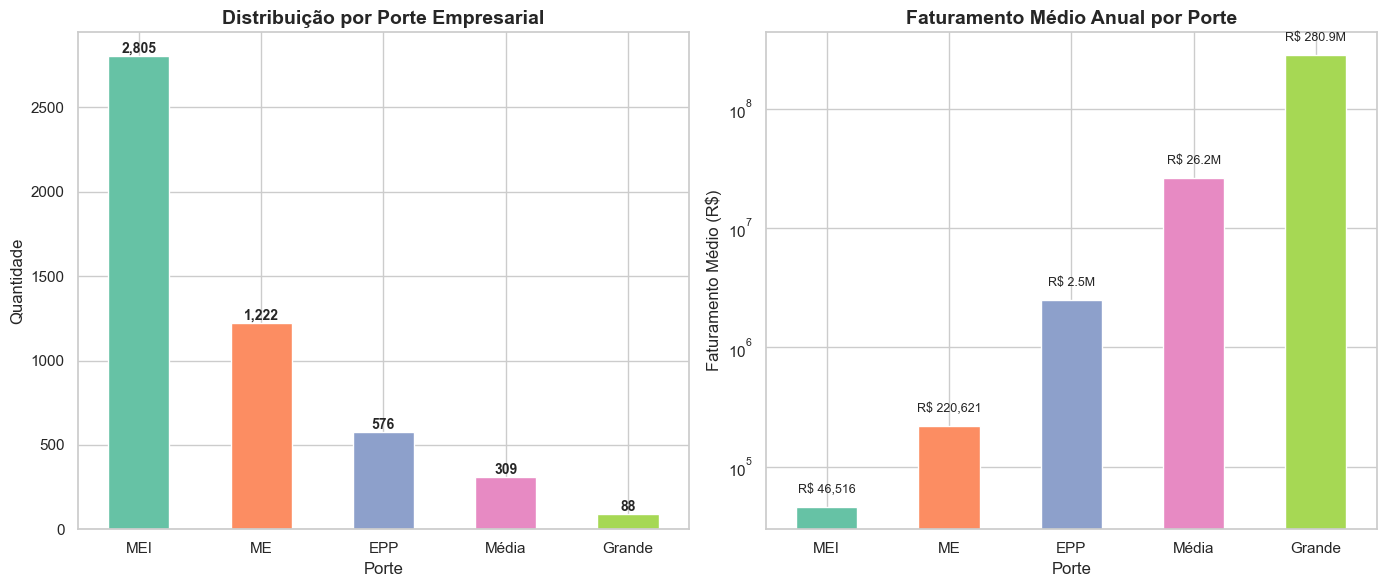

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barras por porte
ordem_porte = ['MEI', 'ME', 'EPP', 'Média', 'Grande']
porte_counts = df['porte'].value_counts().reindex(ordem_porte)
colors_porte = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']
porte_counts.plot(kind='bar', ax=axes[0], color=colors_porte, edgecolor='white')
axes[0].set_title('Distribuição por Porte Empresarial', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Porte')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=0)

for i, val in enumerate(porte_counts.values):
    axes[0].text(i, val + 20, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Faturamento médio por porte (escala log)
fat_por_porte = df.groupby('porte')['faturamento_anual_estimado'].mean().reindex(ordem_porte)
fat_por_porte.plot(kind='bar', ax=axes[1], color=colors_porte, edgecolor='white')
axes[1].set_title('Faturamento Médio Anual por Porte', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Porte')
axes[1].set_ylabel('Faturamento Médio (R$)')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=0)

for i, val in enumerate(fat_por_porte.values):
    label = f'R$ {val:,.0f}' if val < 1_000_000 else f'R$ {val/1_000_000:.1f}M'
    axes[1].text(i, val * 1.3, label, ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/porte_empresarial.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.3 Distribuição Geográfica

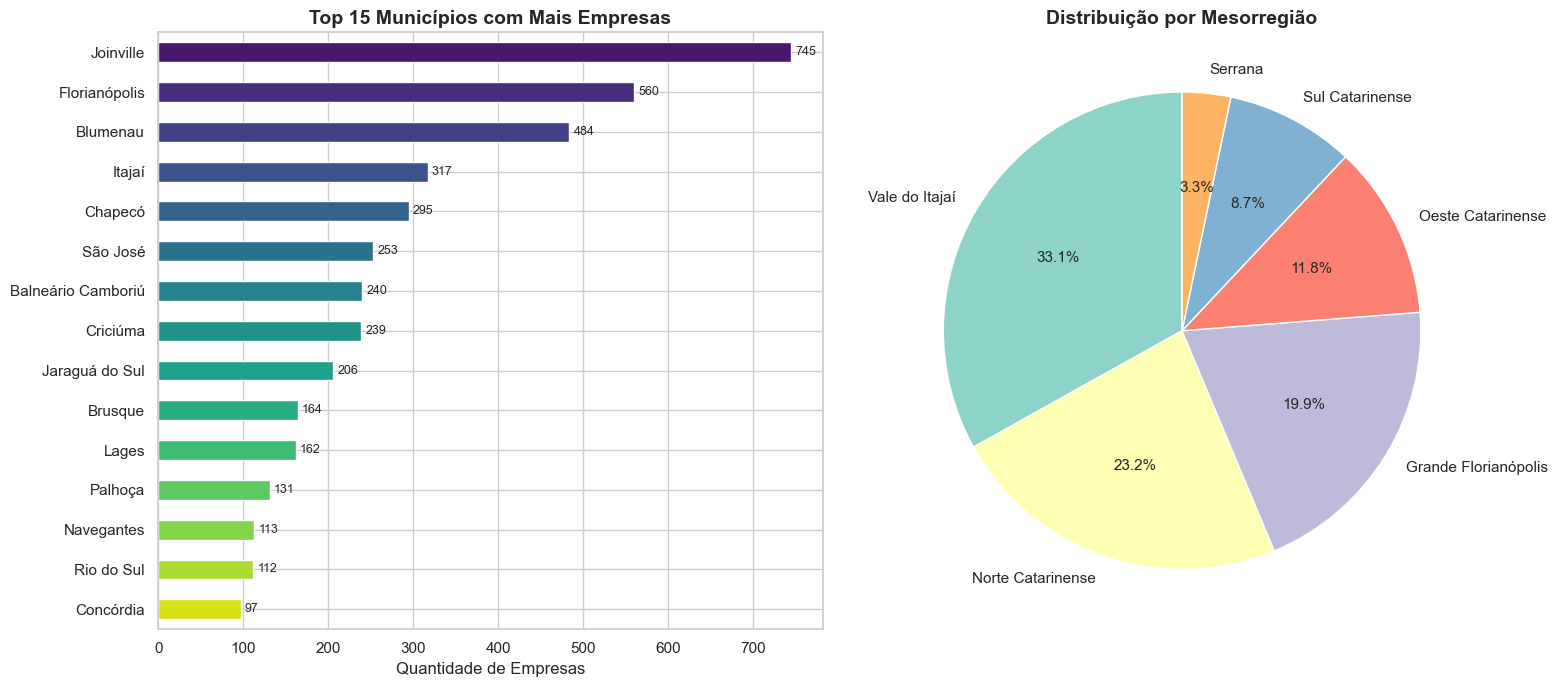

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15 municípios
mun_counts = df[df['municipio'] != 'Não informado']['municipio'].value_counts().head(15)
mun_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', 15))
axes[0].set_title('Top 15 Municípios com Mais Empresas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quantidade de Empresas')
axes[0].set_ylabel('')
axes[0].invert_yaxis()

for i, val in enumerate(mun_counts.values):
    axes[0].text(val + 5, i, f'{val:,}', va='center', fontsize=9)

# Por mesorregião
meso_counts = df[df['mesorregiao'] != 'Não informada']['mesorregiao'].value_counts()
colors_meso = sns.color_palette('Set3', len(meso_counts))
meso_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
                 colors=colors_meso)
axes[1].set_title('Distribuição por Mesorregião', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../outputs/distribuicao_geografica.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.4 Análise Temporal — Abertura de Empresas

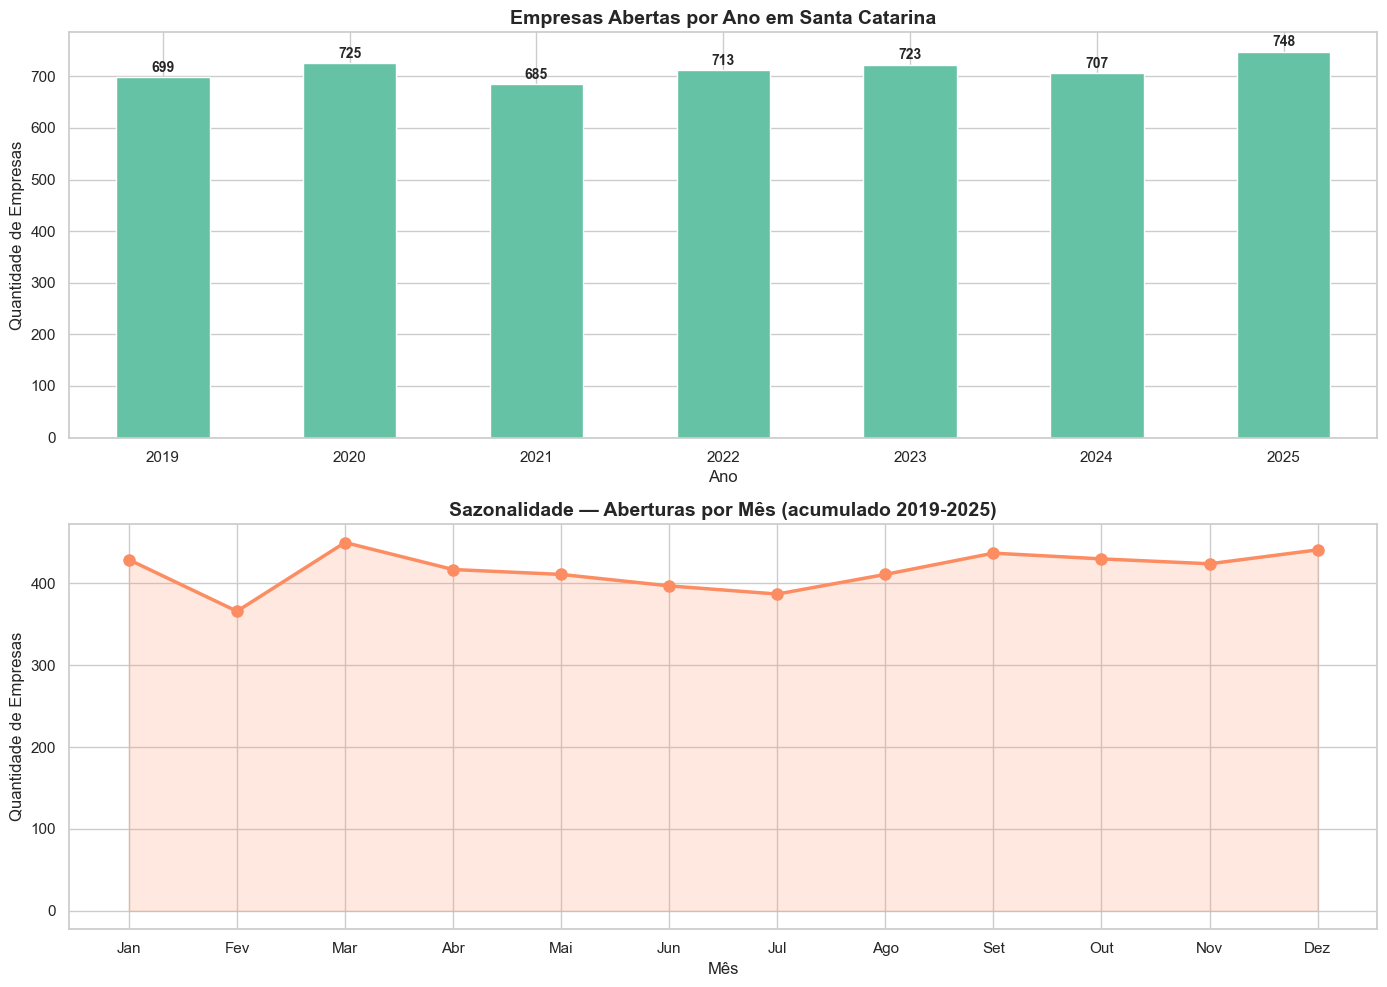

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Abertura por ano
abertura_ano = df.groupby('ano_abertura').size()
abertura_ano.plot(kind='bar', ax=axes[0], color='#66c2a5', edgecolor='white')
axes[0].set_title('Empresas Abertas por Ano em Santa Catarina', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Quantidade de Empresas')
axes[0].tick_params(axis='x', rotation=0)

for i, val in enumerate(abertura_ano.values):
    axes[0].text(i, val + 10, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Abertura por mês (sazonalidade)
abertura_mes = df.groupby('mes_abertura').size()
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
abertura_mes.index = meses
abertura_mes.plot(kind='line', ax=axes[1], marker='o', linewidth=2.5,
                  color='#fc8d62', markersize=8)
axes[1].fill_between(range(12), abertura_mes.values, alpha=0.2, color='#fc8d62')
axes[1].set_title('Sazonalidade — Aberturas por Mês (acumulado 2019-2025)',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Quantidade de Empresas')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(meses)

plt.tight_layout()
plt.savefig('../outputs/analise_temporal.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.5 Taxa de Mortalidade por Setor

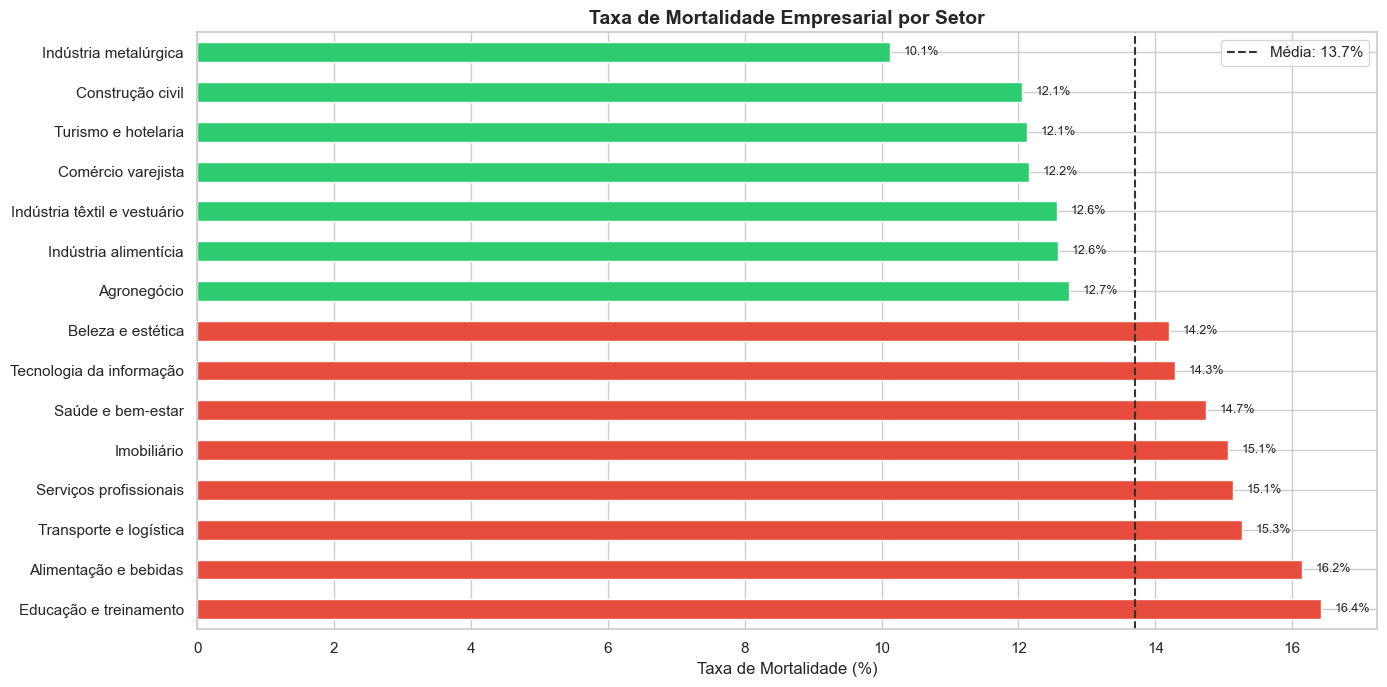

In [14]:
# Calcular taxa de mortalidade (baixadas / total) por setor
mortalidade = df.groupby('setor').apply(
    lambda x: (x['situacao'] == 'Baixada').sum() / len(x) * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#e74c3c' if v > mortalidade.mean() else '#2ecc71' for v in mortalidade.values]
mortalidade.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(mortalidade.mean(), color='#333', linestyle='--', linewidth=1.5,
           label=f'Média: {mortalidade.mean():.1f}%')
ax.set_title('Taxa de Mortalidade Empresarial por Setor', fontsize=14, fontweight='bold')
ax.set_xlabel('Taxa de Mortalidade (%)')
ax.set_ylabel('')
ax.legend(fontsize=11)

for i, val in enumerate(mortalidade.values):
    ax.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/mortalidade_setor.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.6 Capital Social e Funcionários — Correlação

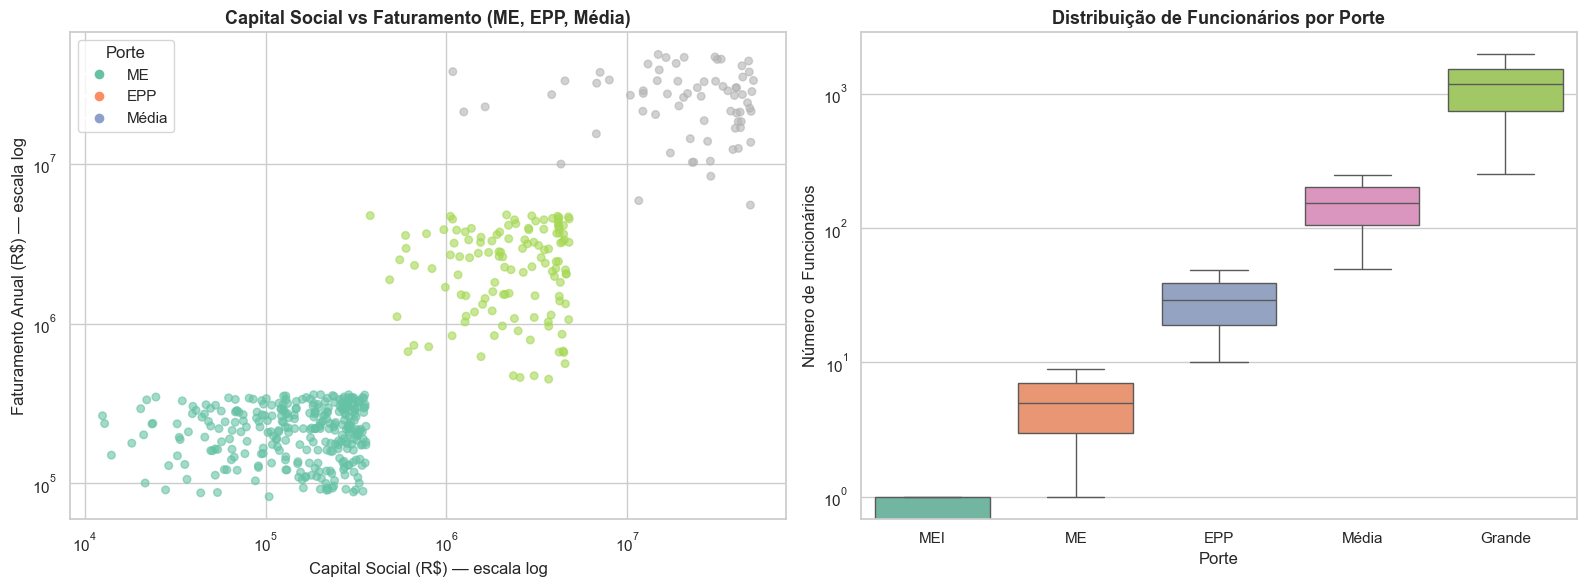

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot capital x faturamento (log scale)
sample = df[df['porte'].isin(['ME', 'EPP', 'Média'])].sample(500, random_state=42)
scatter = axes[0].scatter(sample['capital_social'], sample['faturamento_anual_estimado'],
                          c=sample['porte'].map({'ME': 0, 'EPP': 1, 'Média': 2}),
                          cmap='Set2', alpha=0.6, s=30)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Capital Social vs Faturamento (ME, EPP, Média)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Capital Social (R$) — escala log')
axes[0].set_ylabel('Faturamento Anual (R$) — escala log')
legend_labels = ['ME', 'EPP', 'Média']
handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=sns.color_palette('Set2')[i], markersize=8)
           for i in range(3)]
axes[0].legend(handles, legend_labels, title='Porte')

# Boxplot de funcionários por porte
ordem_porte = ['MEI', 'ME', 'EPP', 'Média', 'Grande']
sns.boxplot(data=df, x='porte', y='num_funcionarios', order=ordem_porte,
            ax=axes[1], palette='Set2')
axes[1].set_title('Distribuição de Funcionários por Porte', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Porte')
axes[1].set_ylabel('Número de Funcionários')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('../outputs/capital_funcionarios.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.7 Heatmap — Setores por Mesorregião

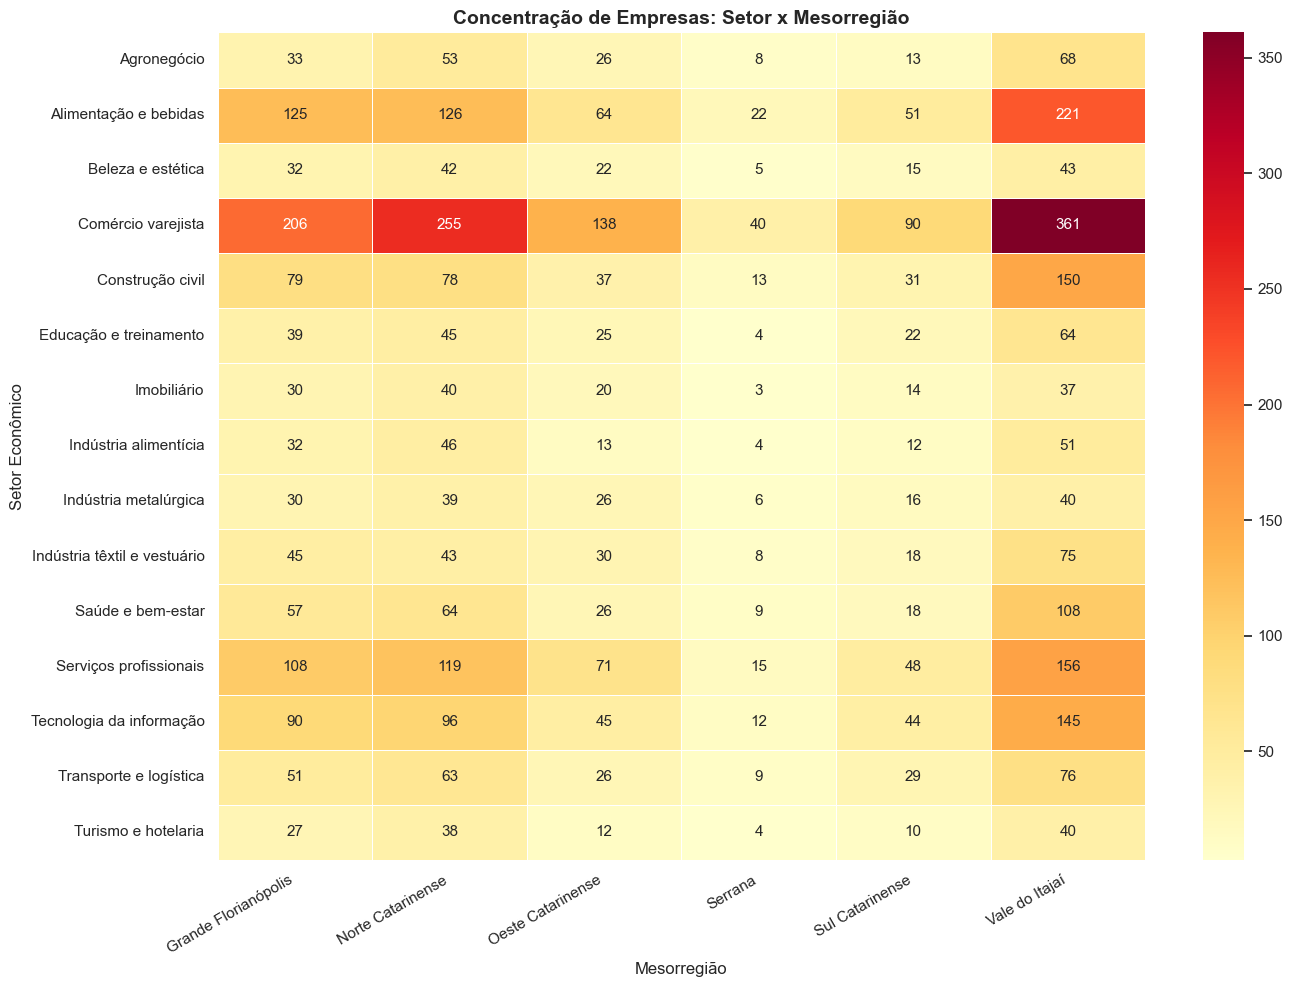

In [16]:
# Criar tabela cruzada setor x mesorregião
cross = pd.crosstab(df['setor'], df['mesorregiao'])
cross = cross.drop(columns=['Não informada'], errors='ignore')

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Concentração de Empresas: Setor x Mesorregião', fontsize=14, fontweight='bold')
ax.set_xlabel('Mesorregião')
ax.set_ylabel('Setor Econômico')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../outputs/heatmap_setor_regiao.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.8 Evolução por Setor ao Longo dos Anos

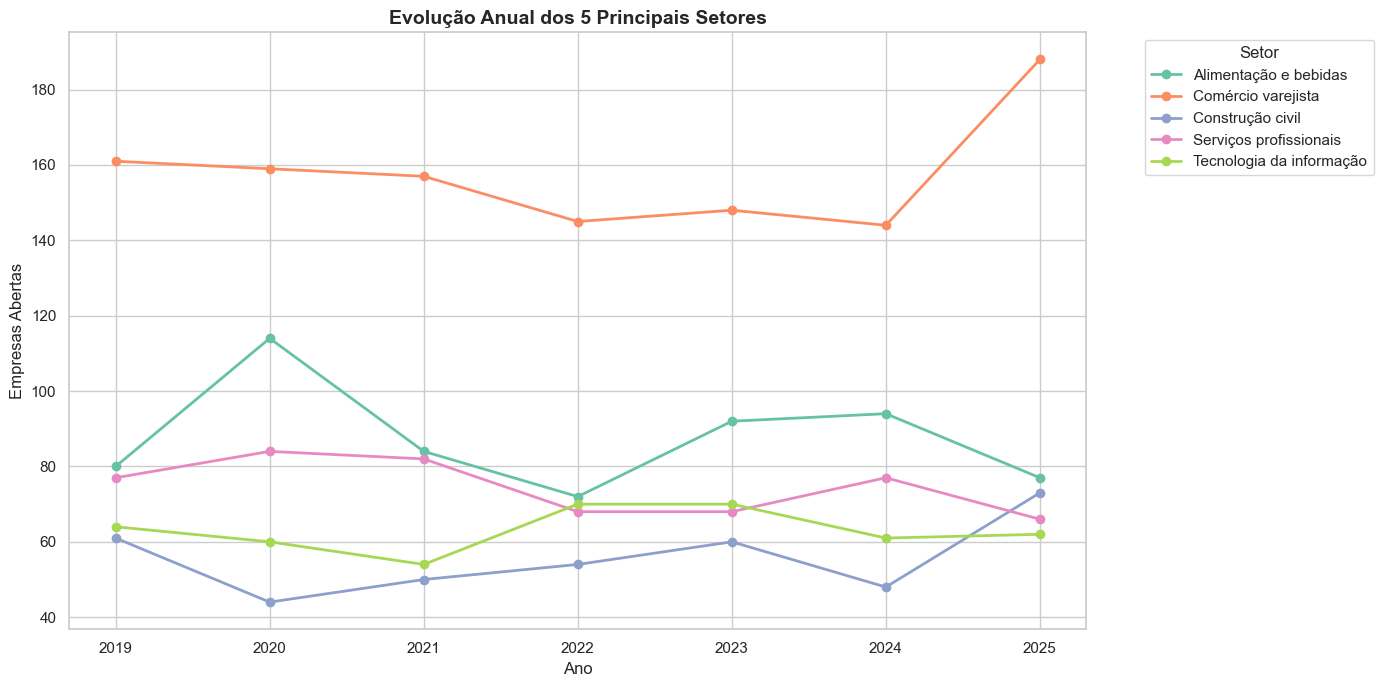

In [17]:
# Top 5 setores — evolução temporal
top5_setores = df['setor'].value_counts().head(5).index.tolist()
df_top5 = df[df['setor'].isin(top5_setores)]

evolucao = df_top5.groupby(['ano_abertura', 'setor']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
evolucao.plot(kind='line', ax=ax, marker='o', linewidth=2)
ax.set_title('Evolução Anual dos 5 Principais Setores', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Empresas Abertas')
ax.legend(title='Setor', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/evolucao_setores.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Conclusões e Insights

### Principais Descobertas

1. **Predominância de MEIs e MEs**: Mais de 80% das empresas catarinenses são de micro porte (MEI ou ME), refletindo o perfil empreendedor do estado fortemente baseado em pequenos negócios.

2. **Concentração no Vale do Itajaí e Norte**: As mesorregiões do Vale do Itajaí e Norte Catarinense concentram a maior parte das empresas, impulsionadas por polos industriais como Joinville, Blumenau e Itajaí.

3. **Comércio varejista lidera**: O setor de comércio varejista é o mais representativo, seguido por alimentação/bebidas e serviços profissionais — padrão consistente com a economia catarinense.

4. **TI em crescimento**: O setor de tecnologia da informação aparece com participação relevante, especialmente concentrado em Florianópolis, Joinville e Blumenau, refletindo os polos de inovação do estado.

5. **Taxa de mortalidade**: A taxa de mortalidade empresarial varia significativamente por setor, com alguns setores apresentando taxas acima da média estadual — informação valiosa para políticas de apoio ao empreendedor.

6. **Sazonalidade**: A abertura de empresas mostra distribuição relativamente uniforme ao longo do ano, sem sazonalidade muito acentuada.

### Limitações
- Os dados são simulados, baseados em distribuições proporcionais reais, mas não representam empresas reais específicas.
- Faturamento e capital social são estimativas baseadas nas faixas de enquadramento de cada porte.

### Possíveis Extensões
- Integração com dados reais da Receita Federal (base CNPJ aberta) para validação das distribuições.
- Modelo preditivo de sobrevivência empresarial com base em setor, porte e localização.
- Análise de correlação com indicadores socioeconômicos municipais (PIB, IDH, emprego).